# GPU-Accelerated Parallel BPE Tokenization
## WikiText-103 Training Pipeline

**Tokenizers compared:**
- `standard_bpe` — sequential CPU BPE (baseline)
- `CudaBPETokenizer` — Parallel BPE_a with CuPy GPU pair counting + wave application

**Workflow:**
1. Environment setup
2. Dataset loading (WikiText-103 + GSM8K)
3. Tokenizer training benchmark
4. Encoding throughput benchmark
5. LM dataset preparation
6. Model training
7. Perplexity evaluation
8. GSM8K numeric integrity (HSG ablation)
9. Final plots & results


## Step 1: Environment Setup


In [1]:
import subprocess, sys

packages = [
    "torch>=2.1.0",
    "transformers>=4.38.0",
    "datasets>=2.18.0",
    "numpy>=1.24.0",
    "tqdm>=4.66.0",
    "ipywidgets>=8.0.0",
    "matplotlib>=3.7.0",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Install CuPy for the GPU-accelerated tokenizer
# Matches CUDA 12.x on Colab T4 — change to cupy-cuda11x if needed
try:
    import cupy
    print(f"CuPy already available: {cupy.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"])
    print("CuPy installed")

print("All dependencies ready")


CuPy already available: 14.0.1
All dependencies ready


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json, time, math, logging
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional
import matplotlib.pyplot as plt
from datasets import load_dataset

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## Step 2: Paths & Logging


In [6]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/PDC")
except Exception:
    IN_COLAB = False
    PROJECT_ROOT = Path(".").resolve()

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_DIR       = PROJECT_ROOT / "cache"
CHECKPOINTS_DIR = CACHE_DIR / "checkpoints"
LOGS_DIR        = CACHE_DIR / "logs"
RESULTS_DIR     = CACHE_DIR / "results"

for d in [CHECKPOINTS_DIR, LOGS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(
            LOGS_DIR / f"train_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
        ),
    ]
)
logger = logging.getLogger("pdc")
logger.info(f"Project root: {PROJECT_ROOT}")
print(f"Project root: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/PDC


## Step 3: Project Imports


In [7]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tokenizer.cuda_bpe import (
    CudaBPETokenizer,
    standard_bpe,
    cuda_bpe,
    CUDA_AVAILABLE,
)
from tokenizer.sequential_bpe import SequentialBPETokenizer
from tokenizer.hsg import SemanticGuardedTokenizer

logger.info(f"CuPy CUDA available: {CUDA_AVAILABLE}")
logger.info("Project modules imported")
print("Project modules imported")

Project modules imported


## Step 4: Dataset Loading — WikiText-103 + GSM8K


In [8]:
BPE_TRAIN_DOCS = 100   # documents for tokenizer training
NUM_MERGES     = 500   # BPE merge rules
LM_TRAIN_DOCS  = 5000   # documents for LM training
MAX_SEQ_LEN    = 256

logger.info("Loading WikiText-103 ...")
wiki_docs = []

try:
    raw_ds = load_dataset(
        "EleutherAI/wikitext_document_level",
        "wikitext-103-raw-v1",
        split="train",
    )
    wiki_docs = [r["text"].strip() for r in raw_ds if len(r["text"].strip()) >= 100]
    logger.info(f"  {len(wiki_docs):,} docs (document-level variant)")

except Exception as e:
    logger.warning(f"  Document-level variant failed ({e}), using Salesforce/wikitext ...")
    raw_ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train")
    current = []
    for row in raw_ds:
        line = row["text"]
        if line.startswith(" = ") and not line.startswith(" = = ") and current:
            doc = " ".join(current).strip()
            if len(doc) >= 100:
                wiki_docs.append(doc)
            current = [line]
        else:
            current.append(line)
    if current:
        doc = " ".join(current).strip()
        if len(doc) >= 100:
            wiki_docs.append(doc)
    logger.info(f"  {len(wiki_docs):,} docs (Salesforce/wikitext fallback)")

bpe_corpus = wiki_docs[:BPE_TRAIN_DOCS]
lm_corpus  = wiki_docs[:LM_TRAIN_DOCS]
val_corpus = wiki_docs[LM_TRAIN_DOCS : LM_TRAIN_DOCS + 500]

total_bpe_chars = sum(len(d) for d in bpe_corpus)
logger.info(f"  BPE corpus : {len(bpe_corpus)} docs | {total_bpe_chars/1e6:.1f} MB")
logger.info(f"  LM corpus  : {len(lm_corpus)} docs")
logger.info(f"  Val corpus : {len(val_corpus)} docs")
print(f"  BPE corpus : {len(bpe_corpus)} docs | {total_bpe_chars/1e6:.1f} MB")
print(f"  LM corpus  : {len(lm_corpus)} docs")
print(f"  Val corpus : {len(val_corpus)} docs")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/wikitext-103-raw-v1-(…):   0%|          | 0.00/305M [00:00<?, ?B/s]

wikitext-103-raw-v1/wikitext-103-raw-v1-(…):   0%|          | 0.00/641k [00:00<?, ?B/s]

wikitext-103-raw-v1/wikitext-103-raw-v1-(…):   0%|          | 0.00/715k [00:00<?, ?B/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

  BPE corpus : 100 docs | 1.8 MB
  LM corpus  : 5000 docs
  Val corpus : 500 docs


In [9]:
logger.info("Loading GSM8K ...")
gsm8k_ds    = load_dataset("gsm8k", "main", split="train")
gsm8k_texts = [f"{r['question']} {r['answer']}" for r in gsm8k_ds]
logger.info(f"  {len(gsm8k_texts):,} GSM8K problems")
print(f"  {len(gsm8k_texts):,} GSM8K problems")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

  7,473 GSM8K problems


## Step 5: Tokenizer Training Benchmark

Both tokenizers train on the **same** `bpe_corpus` with the **same** `NUM_MERGES`.

- `standard_bpe` operates character-level on a joined string (matches original `train_gpu_bpe.ipynb` exactly)
- `CudaBPETokenizer` operates byte-level on the full corpus, using GPU pair counting + wave application


In [10]:
# ── Sequential BPE baseline (byte-level, matches CudaBPETokenizer) ──────
logger.info("=" * 60)
logger.info("Training SequentialBPETokenizer ...")

print("=" * 60)
print("Training SequentialBPETokenizer ...")
seq_tok = SequentialBPETokenizer(vocab_size=50257)

import time as _t
t0 = _t.perf_counter()
seq_merges_done = seq_tok.train(bpe_corpus, num_merges=NUM_MERGES)
t_seq_train = _t.perf_counter() - t0

logger.info(f"  Merges learned : {seq_merges_done}")
logger.info(f"  Training time  : {t_seq_train:.2f}s")

print(f"  Merges learned : {seq_merges_done}")
print(f"  Training time  : {t_seq_train:.2f}s")

Training SequentialBPETokenizer ...
  SequentialBPE: 1,790,048 bytes, target 500 merges


Sequential BPE:   0%|          | 0/500 [00:00<?, ?merge/s]

  SequentialBPE done: 500 merges in 46.02s (92.0 ms/merge avg)
  Merges learned : 500
  Training time  : 47.36s


In [11]:
# ── CuPy GPU BPE (Parallel BPE_a) ────────────────────────────────────────
logger.info("=" * 60)
logger.info("Training CudaBPETokenizer (Parallel BPE_a) ...")

print("=" * 60)
print("Training CudaBPETokenizer (Parallel BPE_a) ...")
gpu_tok = CudaBPETokenizer(vocab_size=50257)

t0 = time.perf_counter()
dag_depth, _ = gpu_tok.train(bpe_corpus, num_merges=NUM_MERGES)
t_gpu_train = time.perf_counter() - t0

parallelism = gpu_tok.parallelism_pct()
logger.info(f"  Merges learned       : {len(gpu_tok.merge_order)}")
logger.info(f"  DAG depth (waves)    : {dag_depth}")
logger.info(f"  Parallelism potential: {parallelism:.1f}%")
logger.info(f"  Training time        : {t_gpu_train:.2f}s")

print(f"  Merges learned       : {len(gpu_tok.merge_order)}")
print(f"  DAG depth (waves)    : {dag_depth}")
print(f"  Parallelism potential: {parallelism:.1f}%")
print(f"  Training time        : {t_gpu_train:.2f}s")

# HSG wrapper for numeric fidelity
hsg_tok = SemanticGuardedTokenizer(gpu_tok, enable_hsg=True)
logger.info("  HSG wrapper created")
print("  HSG wrapper created")

Training CudaBPETokenizer (Parallel BPE_a) ...
  [0/4] Building byte stream from 100 texts...
        Stream length: 1,790,049 bytes  (0.02s)
  [1/4] Speculative merge selection (target 500 merges)...


GPU BPE (speculative):   0%|          | 0/500 [00:00<?, ?merge/s]

  _speculative_select done: 500 merges in 1.73s (3.5 ms/merge avg, dead positions: 563,187)
        500 merges selected  (4.49s)
  [2/4] Building dependency DAG...
        DAG built  (0.00s)
  [3/4] Computing topological waves...
        Levels computed  (0.00s)
        DAG depth: 1 waves (avg 500.0 merges/wave, 99.8% parallelism)
  [4/4] Done. 500 merges, 1 waves
  Merges learned       : 500
  DAG depth (waves)    : 1
  Parallelism potential: 99.8%
  Training time        : 4.51s
  HSG wrapper created


In [12]:
speedup = t_seq_train / t_gpu_train if t_gpu_train > 0 else float("inf")

print("" + "=" * 58)
print("  TOKENIZER TRAINING BENCHMARK")
print("=" * 58)
print(f"  Corpus             : {len(bpe_corpus)} WikiText-103 docs ({total_bpe_chars/1e6:.1f} MB)")
print(f"  Merge rules        : {NUM_MERGES}")
print(f"  CuPy CUDA          : {CUDA_AVAILABLE}")
print()
print(f"  SequentialBPETokenizer : {t_seq_train:.2f}s")
print(f"  CudaBPETokenizer       : {t_gpu_train:.2f}s")
print(f"  Speedup                : {speedup:.2f}x")
print(f"  DAG depth              : {dag_depth} / {NUM_MERGES} ({parallelism:.1f}% parallelism potential)")
print("=" * 58)

  TOKENIZER TRAINING BENCHMARK
  Corpus             : 100 WikiText-103 docs (1.8 MB)
  Merge rules        : 500
  CuPy CUDA          : True

  SequentialBPETokenizer : 47.36s
  CudaBPETokenizer       : 4.51s
  Speedup                : 10.49x
  DAG depth              : 1 / 500 (99.8% parallelism potential)


In [ ]:
import pickle
from pathlib import Path

TOKENIZER_CACHE = CACHE_DIR / "tokenizers"
TOKENIZER_CACHE.mkdir(parents=True, exist_ok=True)

# Save Sequential BPE
seq_path = TOKENIZER_CACHE / f"seq_tok_{BPE_TRAIN_DOCS}docs_{NUM_MERGES}merges.pkl"
with open(seq_path, 'wb') as f:
    pickle.dump({
        'merges':          seq_tok.merges,
        'id_to_pair':      seq_tok.id_to_pair,
        'merge_order':     seq_tok.merge_order,
        '_token_to_bytes': seq_tok._token_to_bytes,
        'vocab_size':      seq_tok.vocab_size,
    }, f)
print(f"Sequential BPE saved -> {seq_path.name}")

# Save GPU BPE
gpu_path = TOKENIZER_CACHE / f"gpu_tok_{BPE_TRAIN_DOCS}docs_{NUM_MERGES}merges.pkl"
with open(gpu_path, 'wb') as f:
    pickle.dump({
        'merge_order': gpu_tok.merge_order,
        'dag_levels':  gpu_tok.dag_levels,
        'id_to_merge': gpu_tok.id_to_merge,
        'vocab_cap':   gpu_tok.vocab_cap,
        'vocab_size':  gpu_tok.vocab_size,
    }, f)
print(f"GPU BPE saved      -> {gpu_path.name}")
print(f"\nSaved to: {TOKENIZER_CACHE}")

## Step 6: Encoding Throughput Benchmark


In [13]:
BENCH_DOCS   = 200
BENCH_WARMUP = 10

bench_wiki  = wiki_docs[LM_TRAIN_DOCS + 500 : LM_TRAIN_DOCS + 500 + BENCH_DOCS]
bench_gsm8k = gsm8k_texts[:BENCH_DOCS]

def measure_encoding(name, encode_fn, texts, warmup=BENCH_WARMUP):
    for t in texts[:warmup]:
        encode_fn(t)
    total_chars  = sum(len(t) for t in texts)
    total_tokens = 0
    t0 = time.perf_counter()
    for t in texts:
        ids = encode_fn(t)
        total_tokens += len(ids) if isinstance(ids, list) else len(ids[0])
    elapsed = time.perf_counter() - t0
    cps = total_chars  / elapsed
    tps = total_tokens / elapsed
    logger.info(f"  {name:<32} {cps/1e6:.2f} M chars/s  {tps/1e3:.1f} K tok/s")
    return cps, tps

TOKENIZERS = [
    ("SequentialBPETokenizer",  seq_tok.encode),
    ("CudaBPETokenizer",         gpu_tok.encode),
    ("CudaBPETokenizer+HSG",     hsg_tok.encode),
]

results = {}
for ds_name, texts in [("WikiText-103", bench_wiki), ("GSM8K", bench_gsm8k)]:
    print(f"--- {ds_name} ({len(texts)} docs) ---")
    results[ds_name] = {}
    for name, enc_fn in TOKENIZERS:
        cps, tps = measure_encoding(name, enc_fn, texts)
        results[ds_name][name] = {"chars_per_sec": cps, "tokens_per_sec": tps}


--- WikiText-103 (200 docs) ---
--- GSM8K (200 docs) ---


In [14]:
print("" + "=" * 68)
print("  ENCODING THROUGHPUT")
print("=" * 68)
for ds_name, ds_res in results.items():
    print(f"{ds_name}")
    print(f"  {'Tokenizer':<34} {'Tokens/s':<18} vs Sequential")
    print("  " + "-" * 60)
    seq_tps = ds_res["SequentialBPETokenizer"]["tokens_per_sec"]
    for name, r in ds_res.items():
        tps   = r["tokens_per_sec"]
        ratio = tps / seq_tps if seq_tps > 0 else 0
        print(f"  {name:<34} {tps/1e3:>8.1f} K/s       {ratio:.2f}x")
print("=" * 68)


  ENCODING THROUGHPUT
WikiText-103
  Tokenizer                          Tokens/s           vs Sequential
  ------------------------------------------------------------
  SequentialBPETokenizer                  8.6 K/s       1.00x
  CudaBPETokenizer                     3919.5 K/s       454.41x
  CudaBPETokenizer+HSG                 3057.8 K/s       354.50x
GSM8K
  Tokenizer                          Tokens/s           vs Sequential
  ------------------------------------------------------------
  SequentialBPETokenizer                  9.4 K/s       1.00x
  CudaBPETokenizer                      133.7 K/s       14.20x
  CudaBPETokenizer+HSG                  393.8 K/s       41.82x


In [ ]:
throughput_results = {
    'config': {
        'bpe_train_docs': BPE_TRAIN_DOCS,
        'num_merges':     NUM_MERGES,
        'bench_docs':     BENCH_DOCS,
        'cuda_available': CUDA_AVAILABLE,
    },
    'training': {
        'seq_time':    t_seq_train,
        'gpu_time':    t_gpu_train,
        'speedup':     speedup,
        'dag_depth':   dag_depth,
        'parallelism': parallelism,
    },
    'encoding': {
        ds: {name: round(r['tokens_per_sec']) for name, r in ds_res.items()}
        for ds, ds_res in results.items()
    }
}

out_path = RESULTS_DIR / 'throughput_results.json'
with open(out_path, 'w') as f:
    json.dump(throughput_results, f, indent=2)
print(f"Saved -> {out_path}")

## Step 7: LM Dataset Preparation


In [18]:
from torch.nn.utils.rnn import pad_sequence

class LazyTokenizedDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=256):
        self.texts      = texts
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.tokenizer.encode(self.texts[idx])
        if isinstance(ids, tuple):
            ids = ids[0][0] if isinstance(ids[0], list) else ids[0].tolist()
        if not ids:
            z = [0] * self.max_length
            return {"input_ids": torch.tensor(z), "labels": torch.tensor(z)}
        start   = max(0, len(ids) - self.max_length - 1)
        inp     = ids[start : start + self.max_length]
        lbl     = ids[start + 1 : start + self.max_length + 1]
        pad_len = self.max_length - len(inp)
        inp = inp + [0] * pad_len
        lbl = lbl + [0] * pad_len
        return {
            "input_ids": torch.tensor(inp[:self.max_length], dtype=torch.long),
            "labels":    torch.tensor(lbl[:self.max_length], dtype=torch.long),
        }

def collate_fn(batch):
    """Pad all sequences in a batch to the same length."""
    input_ids = torch.stack([
        torch.nn.functional.pad(
            b['input_ids'],
            (0, MAX_SEQ_LEN - len(b['input_ids'])),
            value=0
        )[:MAX_SEQ_LEN]
        for b in batch
    ])
    labels = torch.stack([
        torch.nn.functional.pad(
            b['labels'],
            (0, MAX_SEQ_LEN - len(b['labels'])),
            value=0
        )[:MAX_SEQ_LEN]
        for b in batch
    ])
    return {'input_ids': input_ids, 'labels': labels}


BATCH_SIZE  = 8
NUM_WORKERS = 0

train_dataset = LazyTokenizedDataset(lm_corpus,  hsg_tok, MAX_SEQ_LEN)
val_dataset   = LazyTokenizedDataset(val_corpus,  hsg_tok, MAX_SEQ_LEN)
gsm8k_dataset = LazyTokenizedDataset(gsm8k_texts, hsg_tok, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)

logger.info(f"Train : {len(train_dataset):,} | Val : {len(val_dataset):,} | GSM8K : {len(gsm8k_dataset):,}")


## Step 8: Model (GPT-2 Small)


In [19]:
def create_model(vocab_size=50257, hidden_size=256, num_layers=4, nhead=4):
    return nn.Sequential(
        nn.Embedding(vocab_size, hidden_size),
        *[
            nn.TransformerEncoderLayer(
                d_model=hidden_size, nhead=nhead,
                dim_feedforward=hidden_size * 4,
                batch_first=True, dropout=0.1,
            )
            for _ in range(num_layers)
        ],
        nn.Linear(hidden_size, vocab_size),
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = create_model().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Model: {n_params/1e6:.1f}M params on {DEVICE}")


## Step 9: Training Loop


In [20]:
NUM_STEPS  = 2000
LOG_EVERY  = 100
CKPT_EVERY = 500
LR         = 3e-4

optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)

train_losses = []
recent_losses = []
step       = 0
batch_iter = iter(train_loader)
t_train_start = time.perf_counter()

try:
    get_ipython()
    from tqdm.notebook import tqdm
except NameError:
    from tqdm.auto import tqdm

pbar = tqdm(total=NUM_STEPS, desc="Training", unit="step", dynamic_ncols=True)

logger.info(f"Training for {NUM_STEPS} steps ...")

while step < NUM_STEPS:
    model.train()
    try:
        batch = next(batch_iter)
    except StopIteration:
        batch_iter = iter(train_loader)
        batch = next(batch_iter)

    input_ids = batch["input_ids"].to(DEVICE)
    labels    = batch["labels"].to(DEVICE)
    logits    = model(input_ids)
    loss      = criterion(logits.view(-1, 50257), labels.view(-1))

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    train_losses.append(loss.item())
    recent_losses.append(loss.item())
    if len(recent_losses) > LOG_EVERY:
        recent_losses.pop(0)

    avg_recent = sum(recent_losses) / len(recent_losses)

    # Update tqdm bar every step with live loss
    pbar.set_postfix({
        "loss": f"{loss.item():.4f}",
        "avg": f"{avg_recent:.4f}",
        "elapsed": f"{time.perf_counter()-t_train_start:.0f}s",
    })
    pbar.update(1)

    # Periodic logger output (visible in log file too)
    if step % LOG_EVERY == 0:
        elapsed = time.perf_counter() - t_train_start
        logger.info(
            f"  step {step:>5}/{NUM_STEPS} "
            f"| loss {loss.item():.4f} "
            f"| avg(last {LOG_EVERY}) {avg_recent:.4f} "
            f"| {elapsed:.0f}s elapsed"
        )

    if step % CKPT_EVERY == 0 and step > 0:
        ckpt = CHECKPOINTS_DIR / f"checkpoint_{step:05d}.pt"
        torch.save({"step": step, "model": model.state_dict(),
                    "optimizer": optimizer.state_dict()}, ckpt)
        pbar.write(f"  [ckpt] Saved {ckpt.name}")
        logger.info(f"  Checkpoint: {ckpt}")

    step += 1

pbar.close()
t_train_total = time.perf_counter() - t_train_start
logger.info(f"Training done: {NUM_STEPS} steps in {t_train_total:.1f}s  "
            f"({NUM_STEPS/t_train_total:.1f} steps/s)")


Training:   0%|          | 0/2000 [00:00<?, ?step/s]

  [ckpt] Saved checkpoint_00500.pt
  [ckpt] Saved checkpoint_01000.pt
  [ckpt] Saved checkpoint_01500.pt


## Step 10: Perplexity Evaluation


In [23]:
def evaluate_perplexity(model, loader, device):
    model.eval()
    crit = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            logits = model(batch["input_ids"].to(device))
            labels = batch["labels"].to(device)
            total_loss   += crit(logits.view(-1, 50257), labels.view(-1)).item()
            total_tokens += (labels != 0).sum().item()
    avg_loss   = total_loss / max(total_tokens, 1)
    return math.exp(avg_loss), avg_loss


ppl, avg_loss = evaluate_perplexity(model, val_loader, DEVICE)
logger.info(f"Val perplexity : {ppl:.2f}  (loss={avg_loss:.4f})")
print(f"Val perplexity : {ppl:.2f}  (loss={avg_loss:.4f})")

Val perplexity : 11.68  (loss=2.4582)


## Step 11: GSM8K Numeric Integrity — HSG Ablation

Checks what fraction of digit spans survive tokenization intact.
GPU BPE without HSG may fragment multi-digit numbers; HSG locks digit spans before BPE.


In [24]:
import re

def numeric_integrity(texts, encode_fn, decode_fn):
    intact, total = 0, 0
    for text in texts:
        numbers = re.findall(r"\d+", text)
        ids     = encode_fn(text)
        if isinstance(ids, tuple): ids = ids[0]
        decoded = decode_fn(ids)
        for num in numbers:
            total  += 1
            intact += (num in decoded)
    return intact / max(total, 1)


gsm_sample = gsm8k_texts[:200]

configs = [
    ("SequentialBPETokenizer",  seq_tok.encode, seq_tok.decode),
    ("CudaBPETokenizer",         gpu_tok.encode, gpu_tok.decode),
    ("CudaBPETokenizer+HSG",     hsg_tok.encode, hsg_tok.decode),
]

print("" + "=" * 55)
print("  GSM8K NUMERIC INTEGRITY (higher = better)")
print("=" * 55)
for name, enc, dec in configs:
    score = numeric_integrity(gsm_sample, enc, dec)
    print(f"  {name:<34} {score*100:.1f}%")
print("=" * 55)


  GSM8K NUMERIC INTEGRITY (higher = better)
  SequentialBPETokenizer             100.0%
  CudaBPETokenizer                   100.0%
  CudaBPETokenizer+HSG               100.0%


## Step 12: Results Plots


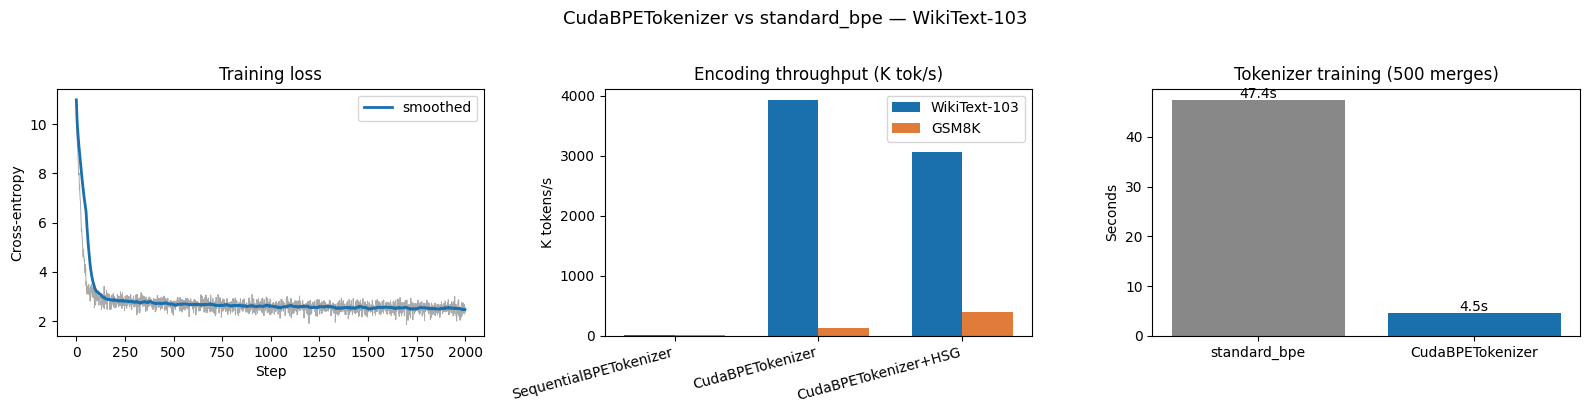

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curve
axes[0].plot(train_losses, lw=0.7, color="#aaa")
smooth = [
    sum(train_losses[max(0,i-50):i+1]) / len(train_losses[max(0,i-50):i+1])
    for i in range(len(train_losses))
]
axes[0].plot(smooth, lw=2, color="#1a6fad", label="smoothed")
axes[0].set(title="Training loss", xlabel="Step", ylabel="Cross-entropy")
axes[0].legend()

# Encoding throughput
tok_names = list(results["WikiText-103"].keys())
wiki_tps  = [results["WikiText-103"][n]["tokens_per_sec"] / 1e3 for n in tok_names]
gsm_tps   = [results["GSM8K"][n]["tokens_per_sec"]        / 1e3 for n in tok_names]
x, w = range(len(tok_names)), 0.35
axes[1].bar([i - w/2 for i in x], wiki_tps, w, label="WikiText-103", color="#1a6fad")
axes[1].bar([i + w/2 for i in x], gsm_tps,  w, label="GSM8K",       color="#e07b39")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(tok_names, rotation=15, ha="right")
axes[1].set(title="Encoding throughput (K tok/s)", ylabel="K tokens/s")
axes[1].legend()

# Training time
labels = ["standard_bpe", "CudaBPETokenizer"]
times  = [t_seq_train, t_gpu_train]
axes[2].bar(labels, times, color=["#888", "#1a6fad"])
axes[2].set(title=f"Tokenizer training ({NUM_MERGES} merges)", ylabel="Seconds")
for i, v in enumerate(times):
    axes[2].text(i, v + 0.5, f"{v:.1f}s", ha="center", fontsize=10)

plt.suptitle("CudaBPETokenizer vs standard_bpe — WikiText-103", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "results.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Plot saved to {RESULTS_DIR}/results.png")


## Step 13: Final Summary & Save


In [26]:
print("" + "="*60)
print("  FINAL RESULTS")
print("="*60)
print(f"  Dataset            : WikiText-103 ({len(bpe_corpus)} docs, {total_bpe_chars/1e6:.1f} MB)")
print(f"  Merge rules        : {NUM_MERGES}  |  CuPy CUDA: {CUDA_AVAILABLE}")
print(f"  DAG depth          : {dag_depth} ({parallelism:.1f}% parallelism potential)")
print()
print(f"  [Training speed]")
print(f"    SequentialBPETokenizer : {t_seq_train:.2f}s")
print(f"    CudaBPETokenizer       : {t_gpu_train:.2f}s  ({speedup:.2f}x faster)")
print()
print(f"  [Encoding — WikiText-103]")
for n, r in results["WikiText-103"].items():
    print(f"    {n:<32} : {r['tokens_per_sec']/1e3:.1f} K tok/s")
print()
print(f"  [Encoding — GSM8K]")
for n, r in results["GSM8K"].items():
    print(f"    {n:<32} : {r['tokens_per_sec']/1e3:.1f} K tok/s")
print()
print(f"  [LM quality]")
print(f"    Val perplexity         : {ppl:.2f}  (loss={avg_loss:.4f})")
print(f"    Steps / time           : {NUM_STEPS} / {t_train_total:.0f}s")
print("="*60)

out = {
    "dataset": "wikitext-103",
    "cuda_available": CUDA_AVAILABLE,
    "bpe_corpus_docs": len(bpe_corpus),
    "num_merges": NUM_MERGES,
    "dag_depth": dag_depth,
    "parallelism_pct": round(parallelism, 2),
    "t_seq_train": round(t_seq_train, 3),
    "t_gpu_train": round(t_gpu_train, 3),
    "speedup": round(speedup, 3),
    "encoding": {
        ds: {n: round(r["tokens_per_sec"]) for n, r in v.items()}
        for ds, v in results.items()
    },
    "val_perplexity": round(ppl, 4),
    "val_loss": round(avg_loss, 4),
    "lm_steps": NUM_STEPS,
    "lm_seconds": round(t_train_total, 1),
}
p = RESULTS_DIR / "final_results.json"
with open(p, "w") as f:
    json.dump(out, f, indent=2)
logger.info(f"Results saved to {p}")


  FINAL RESULTS
  Dataset            : WikiText-103 (100 docs, 1.8 MB)
  Merge rules        : 500  |  CuPy CUDA: True
  DAG depth          : 1 (99.8% parallelism potential)

  [Training speed]
    SequentialBPETokenizer : 47.36s
    CudaBPETokenizer       : 4.51s  (10.49x faster)

  [Encoding — WikiText-103]
    SequentialBPETokenizer           : 8.6 K tok/s
    CudaBPETokenizer                 : 3919.5 K tok/s
    CudaBPETokenizer+HSG             : 3057.8 K tok/s

  [Encoding — GSM8K]
    SequentialBPETokenizer           : 9.4 K tok/s
    CudaBPETokenizer                 : 133.7 K tok/s
    CudaBPETokenizer+HSG             : 393.8 K tok/s

  [LM quality]
    Val perplexity         : 11.68  (loss=2.4582)
    Steps / time           : 2000 / 291s
